#### Re-Identification with Feature Extraction

This experiment illustrates a more realistic scenario where the patient identities are attempted to be extracted from the clinical utility trained models.

### Config

In [1]:
# ==========================================
# CELL 1: REID FEATURE EXTRACTION — SETUP
# ==========================================

import os, json, re, math, random
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import torch

# --------------------------
# REPO-RELATIVE ROOT
# --------------------------
# Assumes you run notebook from repo root (reid_clean/).
# If not, set REPO_ROOT manually.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists():
    # fallback: if notebook lives inside repo root
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "data").exists() and (p / "results").exists():
            REPO_ROOT = p
            break

DATASET = "oasis"

DATA_UTILITY_DIR = REPO_ROOT / "data" / DATASET / "processed" / "utility"
MODELS_UTILITY_DIR = REPO_ROOT / "models" / DATASET / "utility"
RESULTS_DIR = REPO_ROOT / "results" / DATASET / "reid_feature_ext"
CACHE_DIR = REPO_ROOT / "cache" / DATASET / "reid_feature_ext"  # optional

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------
# SWITCHES (CRITICAL)
# --------------------------
RESUME_IF_EXISTS = True
CACHE_ENABLED = False   # OFF by default (GitHub-safe)

# --------------------------
# EXPERIMENT GRID (LOCKED)
# --------------------------
FOLDS = [0, 1, 2, 3, 4]
CONDITIONS = ["raw", "gs0", "gs10", "gs20", "gs30", "gs40", "gs50"]

# evaluation splits: keep both (seen/unseen) as in original
EVAL_SPLITS = ["train", "test"]

ATTACKERS = ["adaptive", "blind"]  # blind = GS-trained evaluated on RAW

K_PROBE_LIST = [1]
K_GALLERY_LIST = [1, 3, 5]

# --------------------------
# DETERMINISM
# --------------------------
GLOBAL_SEED = 1337
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ DEVICE:", DEVICE)

# --------------------------
# HARD FAIL (reviewer-safe)
# --------------------------
def _hard_fail(msg: str):
    raise RuntimeError(f"[HARD FAIL] {msg}")

# --------------------------
# LOAD FOLDS (from utility processed)
# --------------------------
def load_folds_from_utility() -> Dict[str, Dict[str, List[str]]]:
    # Accept either folds.json or folds_5_subject.json etc.
    candidates = [
        DATA_UTILITY_DIR / "folds.json",
        DATA_UTILITY_DIR / "folds_5_subject.json",
        DATA_UTILITY_DIR / "splits.json",
    ]
    path = next((p for p in candidates if p.exists()), None)
    if path is None:
        _hard_fail(
            "Missing folds json under data/oasis/processed/utility/. "
            f"Tried: {[str(p) for p in candidates]}"
        )

    with open(path, "r") as f:
        folds = json.load(f)

    # Expected: {"fold_0": {"train":[...], "val":[...], "test":[...]}, ...}
    for k in [f"fold_{i}" for i in FOLDS]:
        if k not in folds:
            _hard_fail(f"Folds JSON missing key '{k}'. Present keys: {list(folds.keys())[:10]}")
        for split in ["train", "val", "test"]:
            if split not in folds[k]:
                _hard_fail(f"Folds JSON '{k}' missing split '{split}'. Keys: {list(folds[k].keys())}")
            if not isinstance(folds[k][split], list) or len(folds[k][split]) == 0:
                _hard_fail(f"Folds JSON '{k}/{split}' must be a non-empty list of subject_ids.")
            if not isinstance(folds[k][split][0], str):
                _hard_fail(f"Folds JSON '{k}/{split}' subject_ids must be strings.")
    print(f"✅ Loaded folds from: {path}")
    return folds

folds = load_folds_from_utility()

def assert_no_subject_overlap(fold_idx: int):
    tr = set(folds[f"fold_{fold_idx}"]["train"])
    te = set(folds[f"fold_{fold_idx}"]["test"])
    inter = tr.intersection(te)
    if len(inter) != 0:
        _hard_fail(f"Subject leakage detected: fold {fold_idx} train∩test size={len(inter)} examples={list(inter)[:5]}")

# --------------------------
# DISCOVER MODEL GRID (utility models)
# --------------------------
def discover_model_grid(models_root: Path) -> Tuple[List[str], List[str]]:
    """
    Discover available architectures + init modes under models/oasis/utility.
    We support either:
      (A) models/oasis/utility/{arch}/{init}/...  (preferred)
      (B) models/oasis/utility/{arch}/...         (infer init from filenames)
    """
    if not models_root.exists():
        _hard_fail(f"MODELS_UTILITY_DIR not found: {models_root}")

    archs = sorted([d.name for d in models_root.iterdir() if d.is_dir()])
    if not archs:
        _hard_fail(f"No architectures found under {models_root}")

    inits_all = set()
    for arch in archs:
        subdirs = [d.name for d in (models_root / arch).iterdir() if d.is_dir()]
        # if subdirs look like init modes:
        for s in subdirs:
            if s.lower() in ["pretrained", "scratch"]:
                inits_all.add(s.lower())

    # if init dirs exist, use intersection across archs
    if inits_all:
        init_sets = []
        for arch in archs:
            init_modes = sorted([
                d.name.lower() for d in (models_root / arch).iterdir()
                if d.is_dir() and d.name.lower() in ["pretrained", "scratch"]
            ])
            init_sets.append(set(init_modes))
        common_inits = sorted(list(set.intersection(*init_sets)))
        if not common_inits:
            _hard_fail("No common init modes across architectures in models/oasis/utility.")
        return archs, common_inits

    # otherwise, fall back to default two (we will validate later by checkpoint lookup)
    return archs, ["pretrained", "scratch"]

ARCHS, INITS = discover_model_grid(MODELS_UTILITY_DIR)

print("✅ Discovered architectures:", ARCHS)
print("✅ Discovered init modes:", INITS)
print("✅ Conditions:", CONDITIONS)
print("✅ Folds:", FOLDS)


✅ DEVICE: cuda
✅ Loaded folds from: /home/jupyter/notebooks/reid_clean/data/oasis/processed/utility/folds.json
✅ Discovered architectures: ['densenet121', 'resnet18']
✅ Discovered init modes: ['pretrained', 'scratch']
✅ Conditions: ['raw', 'gs0', 'gs10', 'gs20', 'gs30', 'gs40', 'gs50']
✅ Folds: [0, 1, 2, 3, 4]


In [2]:
# ==========================================
# CELL 2: RAW DATA LOADING + SLICE SELECTION
# ==========================================

import math
import pickle
from collections import defaultdict
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import torch

# --------------------------
# Gallery / probe rules (LOCKED - same as original)
# --------------------------
GALLERY_FRACTION = 0.5
MIN_GALLERY_PER_SUBJ = 1
MIN_PROBE_PER_SUBJ = 1

# --------------------------
# Load band_data.pkl ONCE
# --------------------------
BAND_DATA_PKL = DATA_UTILITY_DIR / "band_data.pkl"
if not BAND_DATA_PKL.exists():
    _hard_fail(f"Missing band_data.pkl at {BAND_DATA_PKL}")

with open(BAND_DATA_PKL, "rb") as f:
    BAND_DATA = pickle.load(f)

IMAGES_ALL   = BAND_DATA["images"]     # (N,H,W) float32 [0,1]
LABELS_ALL   = BAND_DATA["labels"]     # (N,)
SUBJECTS_ALL = BAND_DATA["subjects"]   # list[str]

print(f"✅ Loaded band_data.pkl: {IMAGES_ALL.shape[0]} slices")

# --------------------------
# Helpers (same as original)
# --------------------------
def group_indices_by_subject(sid_list: List[str]) -> Dict[str, List[int]]:
    groups = defaultdict(list)
    for i, s in enumerate(sid_list):
        groups[s].append(i)
    return groups


def deterministic_split_indices_per_subject(
    sid_list: List[str],
    gallery_fraction: float = GALLERY_FRACTION,
    seed: int = GLOBAL_SEED,
    max_gallery_per_subject: Optional[int] = None,
    max_probe_per_subject: Optional[int] = None,
) -> Tuple[List[int], List[int], List[str]]:
    """
    Returns:
      gallery_idx: list of indices
      probe_idx: list of indices  
      kept_subjects: subjects that had enough slices for both sides
    """
    groups = group_indices_by_subject(sid_list)
    gallery_idx, probe_idx = [], []
    kept_subjects = []

    for subj, idxs in groups.items():
        if len(idxs) < (MIN_GALLERY_PER_SUBJ + MIN_PROBE_PER_SUBJ):
            continue

        # Stable shuffle: seed derived from global seed and subject id
        r = random.Random(hash((seed, subj)) & 0xFFFFFFFF)
        idxs_shuf = idxs.copy()
        r.shuffle(idxs_shuf)

        n = len(idxs_shuf)
        n_g = int(math.floor(n * gallery_fraction))
        n_g = max(n_g, MIN_GALLERY_PER_SUBJ)
        n_g = min(n_g, n - MIN_PROBE_PER_SUBJ)

        g = idxs_shuf[:n_g]
        p = idxs_shuf[n_g:]

        if len(g) < MIN_GALLERY_PER_SUBJ or len(p) < MIN_PROBE_PER_SUBJ:
            continue

        # K-tuning caps
        if max_gallery_per_subject is not None:
            g = g[:max_gallery_per_subject]
        if max_probe_per_subject is not None:
            p = p[:max_probe_per_subject]

        # Re-check after capping
        if len(g) < MIN_GALLERY_PER_SUBJ or len(p) < MIN_PROBE_PER_SUBJ:
            continue

        gallery_idx.extend(g)
        probe_idx.extend(p)
        kept_subjects.append(subj)

    if len(kept_subjects) == 0:
        _hard_fail("No subjects had enough slices to form gallery/probe split.")

    return gallery_idx, probe_idx, kept_subjects


def load_raw_split_data(fold_idx: int, split: str) -> Dict[str, Any]:
    """
    Load RAW (un-transformed) data for a given fold and split.
    Returns dict with x (tensor), y (tensor), sid (list).
    """
    if split not in ["train", "test", "val"]:
        _hard_fail(f"Invalid split={split}")

    fold_key = f"fold_{fold_idx}"
    allowed_subjects = set(folds[fold_key][split])

    idx = [i for i, s in enumerate(SUBJECTS_ALL) if s in allowed_subjects]
    if not idx:
        _hard_fail(f"No slices for fold={fold_idx}, split={split}")

    x_np = IMAGES_ALL[idx]
    y_np = LABELS_ALL[idx]
    sid = [SUBJECTS_ALL[i] for i in idx]

    # Sanity: data should be in [0,1]
    if np.min(x_np) < 0 or np.max(x_np) > 1:
        _hard_fail("RAW images not normalized to [0,1]")

    # Convert to tensor: (N, 1, H, W)
    x = torch.from_numpy(x_np).unsqueeze(1).float()
    y = torch.as_tensor(y_np, dtype=torch.int64)

    return {"x": x, "y": y, "sid": sid}


def build_gallery_probe_raw(
    fold_idx: int,
    split: str,
    k_gallery: Optional[int] = None,
    k_probe: Optional[int] = None,
    seed: int = GLOBAL_SEED,
) -> Dict[str, Any]:
    """
    Build gallery/probe split from RAW data.
    GS will be applied later in Cell 3.
    """
    base = load_raw_split_data(fold_idx, split)

    g_idx, p_idx, kept_subjects = deterministic_split_indices_per_subject(
        base["sid"],
        seed=seed,
        max_gallery_per_subject=k_gallery,
        max_probe_per_subject=k_probe,
    )

    return {
        "gallery": {
            "x": base["x"][g_idx],
            "y": base["y"][g_idx],
            "sid": [base["sid"][i] for i in g_idx],
        },
        "probe": {
            "x": base["x"][p_idx],
            "y": base["y"][p_idx],
            "sid": [base["sid"][i] for i in p_idx],
        },
        "kept_subjects": kept_subjects,
    }


# --------------------------
# Sanity check
# --------------------------
assert_no_subject_overlap(0)
tmp = build_gallery_probe_raw(0, "test", k_gallery=3, k_probe=1)
print("✅ Cell 2 OK:")
print(f"   Gallery: {tmp['gallery']['x'].shape}")
print(f"   Probe: {tmp['probe']['x'].shape}")
print(f"   Subjects: {len(tmp['kept_subjects'])}")

✅ Loaded band_data.pkl: 43927 slices
✅ Cell 2 OK:
   Gallery: torch.Size([210, 1, 224, 224])
   Probe: torch.Size([70, 1, 224, 224])
   Subjects: 70


In [3]:
# ==========================================
# CELL 3: LOAD UTILITY MODELS + EMBEDDINGS
# ==========================================

import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
from collections import defaultdict
from gs_functions import GS_batch_image

# --------------------------
# Constants (LOCKED - same as original)
# --------------------------
BATCH_SIZE_EMB = 128
NUM_CLASSES = 2
DROPOUT_P = 0.4
GS_BATCH_SIZE = 300
GS_ITERS = 50

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ DEVICE:", DEVICE)

# --------------------------
# Optional cache for GS-transformed data
# --------------------------
_GS_CACHE = {}  # key: (condition, tuple of slice indices) -> transformed tensor


def apply_gs_to_tensor(x: torch.Tensor, condition: str, use_cache: bool = False) -> torch.Tensor:
    """
    Apply GradientShaping transform based on condition.
    
    - "raw": No transform (return as-is)
    - "gs0", "gs10", ..., "gs50": Apply GS with corresponding mask percentage
    
    NOTE: Unlike the original framework which loaded pre-computed caches,
    this applies GS on-the-fly to save memory.
    """
    condition = condition.strip().lower()
    
    # RAW = no transform
    if condition == "raw":
        return x
    
    # Parse GS level
    if not condition.startswith("gs"):
        _hard_fail(f"Unknown condition: {condition}. Expected 'raw' or 'gsXX'.")
    
    try:
        mask_level = int(condition.replace("gs", ""))
    except ValueError:
        _hard_fail(f"Cannot parse mask level from condition: {condition}")
    
    maskP = mask_level / 100.0
    
    # Optional caching
    if use_cache and CACHE_ENABLED:
        cache_key = (condition, x.shape, id(x))
        if cache_key in _GS_CACHE:
            return _GS_CACHE[cache_key]
    
    # Apply GS transform
    x_np = x.squeeze(1).cpu().numpy()  # (N, H, W)
    
    x_gs = GS_batch_image(
        data=x_np,
        batch_size=GS_BATCH_SIZE,
        ite=GS_ITERS,
        maskP=maskP,
    )
    
    if x_gs.shape != x_np.shape:
        _hard_fail(f"GS output shape mismatch: input {x_np.shape}, output {x_gs.shape}")
    
    result = torch.from_numpy(x_gs).unsqueeze(1).float()
    
    # Cache if enabled
    if use_cache and CACHE_ENABLED:
        _GS_CACHE[cache_key] = result
    
    return result


# --------------------------
# Subject aggregation (same as original)
# --------------------------
def mean_embeddings_by_subject(
    emb: torch.Tensor,
    sid_list: List[str],
) -> Tuple[torch.Tensor, List[str]]:
    """Average embeddings per subject and re-normalize."""
    groups = defaultdict(list)
    for i, s in enumerate(sid_list):
        groups[s].append(i)

    subj_ids = sorted(groups.keys())
    subj_embs = []

    for s in subj_ids:
        idx = groups[s]
        m = emb[idx].mean(dim=0, keepdim=True)
        m = F.normalize(m, p=2, dim=1)
        subj_embs.append(m)

    return torch.cat(subj_embs, dim=0), subj_ids


# --------------------------
# Checkpoint helpers (same as original)
# --------------------------
def _strip_state_dict_prefix(sd: dict) -> dict:
    if any(k.startswith("module.") for k in sd):
        return {k.replace("module.", "", 1): v for k, v in sd.items()}
    return sd


def _looks_like_state_dict(d: dict) -> bool:
    if not isinstance(d, dict) or len(d) == 0:
        return False
    for k, v in list(d.items())[:20]:
        if not isinstance(k, str) or not torch.is_tensor(v):
            return False
    return True


# --------------------------
# Model construction (same as original)
# --------------------------
def build_model_like_utility(arch: str, init_mode: str) -> nn.Module:
    pretrained = (init_mode.lower() == "pretrained")
    weights = None

    if pretrained:
        if arch == "resnet18":
            weights = tvm.ResNet18_Weights.DEFAULT
        elif arch == "densenet121":
            weights = tvm.DenseNet121_Weights.DEFAULT
        else:
            _hard_fail(f"Unsupported arch={arch}")

    if arch == "resnet18":
        model = tvm.resnet18(weights=weights)
        old_conv = model.conv1
        model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained:
            with torch.no_grad():
                model.conv1.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
        else:
            nn.init.kaiming_normal_(model.conv1.weight, mode="fan_out", nonlinearity="relu")

        num_ftrs = model.fc.in_features
        head_linear = nn.Linear(num_ftrs, NUM_CLASSES)
        nn.init.xavier_uniform_(head_linear.weight)
        nn.init.zeros_(head_linear.bias)
        model.fc = nn.Sequential(nn.Dropout(p=DROPOUT_P), head_linear)
        return model

    if arch == "densenet121":
        model = tvm.densenet121(weights=weights, memory_efficient=True)
        old_conv = model.features.conv0
        model.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained:
            with torch.no_grad():
                model.features.conv0.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
        else:
            nn.init.kaiming_normal_(model.features.conv0.weight, mode="fan_out", nonlinearity="relu")

        num_ftrs = model.classifier.in_features
        head_linear = nn.Linear(num_ftrs, NUM_CLASSES)
        nn.init.xavier_uniform_(head_linear.weight)
        nn.init.zeros_(head_linear.bias)
        model.classifier = nn.Sequential(nn.Dropout(p=DROPOUT_P), head_linear)
        return model

    _hard_fail(f"Unsupported arch={arch}")


# --------------------------
# Checkpoint loading (same as original)
# --------------------------
def find_utility_checkpoint(
    arch: str,
    init_mode: str,
    condition: str,
    fold_idx: int
) -> Path:
    """
    Expected layout: models/oasis/utility/{arch}/{init}/{condition}/fold_{k}.pt
    """
    p = MODELS_UTILITY_DIR / arch / init_mode / condition / f"fold_{fold_idx}.pt"
    if not p.exists():
        _hard_fail(
            f"Missing utility checkpoint:\n"
            f"  arch={arch}, init={init_mode}, condition={condition}, fold={fold_idx}\n"
            f"  expected: {p}"
        )
    return p


def load_utility_model(
    arch: str,
    init_mode: str,
    condition: str,
    fold_idx: int
) -> nn.Module:
    ckpt_path = find_utility_checkpoint(arch, init_mode, condition, fold_idx)
    obj = torch.load(ckpt_path, map_location="cpu")

    if isinstance(obj, dict) and "state_dict" in obj:
        sd = obj["state_dict"]
    elif _looks_like_state_dict(obj):
        sd = obj
    else:
        _hard_fail(f"Unrecognized checkpoint format at {ckpt_path}")

    sd = _strip_state_dict_prefix(sd)

    model = build_model_like_utility(arch, init_mode)
    model.load_state_dict(sd, strict=True)
    model.eval().to(DEVICE)
    return model


# --------------------------
# Embedding extractor (same as original)
# --------------------------
def build_penultimate_extractor(model: nn.Module, arch: str) -> nn.Module:
    if arch == "resnet18":
        class ResNet18Embedder(nn.Module):
            def __init__(self, m):
                super().__init__()
                self.m = m
            def forward(self, x):
                x = self.m.conv1(x)
                x = self.m.bn1(x)
                x = self.m.relu(x)
                x = self.m.maxpool(x)
                x = self.m.layer1(x)
                x = self.m.layer2(x)
                x = self.m.layer3(x)
                x = self.m.layer4(x)
                x = self.m.avgpool(x)
                x = torch.flatten(x, 1)
                return x
        return ResNet18Embedder(model).eval().to(DEVICE)

    if arch == "densenet121":
        class DenseNet121Embedder(nn.Module):
            def __init__(self, m):
                super().__init__()
                self.m = m
            def forward(self, x):
                x = self.m.features(x)
                x = F.relu(x, inplace=False)
                x = F.adaptive_avg_pool2d(x, (1, 1))
                x = torch.flatten(x, 1)
                return x
        return DenseNet121Embedder(model).eval().to(DEVICE)

    _hard_fail(f"Unsupported arch for embedder: {arch}")


@torch.no_grad()
def extract_embeddings(x: torch.Tensor, embedder: nn.Module) -> torch.Tensor:
    """Extract L2-normalized embeddings in batches."""
    outs = []
    for i in range(0, x.shape[0], BATCH_SIZE_EMB):
        xb = x[i:i + BATCH_SIZE_EMB].to(DEVICE, non_blocking=True)
        eb = embedder(xb).float()
        eb = F.normalize(eb, p=2, dim=1)
        outs.append(eb.detach().cpu())
    return torch.cat(outs, dim=0)


# --------------------------
# Main embedding function (matches original logic)
# --------------------------
def embed_gallery_probe_for_one_setting(
    fold_idx: int,
    arch: str,
    init_mode: str,
    train_condition: str,
    attacker_type: str,
    eval_split: str,
    seed: int = GLOBAL_SEED,
    k_gallery: Optional[int] = None,
    k_probe: Optional[int] = None,
) -> dict:
    """
    Main function that matches original framework behavior.
    
    Key difference from original:
    - Original loaded pre-computed GS caches
    - This applies GS on-the-fly to raw data
    """
    assert_no_subject_overlap(fold_idx)

    # Determine eval condition based on attacker type (same as original)
    if attacker_type == "adaptive":
        eval_condition = train_condition
    elif attacker_type == "blind":
        eval_condition = "raw"
    else:
        _hard_fail(f"Invalid attacker_type: {attacker_type}")

    # Step 1: Load RAW gallery/probe split
    gp = build_gallery_probe_raw(
        fold_idx=fold_idx,
        split=eval_split,
        k_gallery=k_gallery,
        k_probe=k_probe,
        seed=seed,
    )

    # Step 2: Apply GS transform based on eval_condition
    # (This replaces the cache loading in original)
    g_x = apply_gs_to_tensor(gp["gallery"]["x"], eval_condition)
    p_x = apply_gs_to_tensor(gp["probe"]["x"], eval_condition)

    g_sid = gp["gallery"]["sid"]
    p_sid = gp["probe"]["sid"]

    # Step 3: Load model (trained on train_condition)
    model = load_utility_model(arch, init_mode, train_condition, fold_idx)
    embedder = build_penultimate_extractor(model, arch)

    # Step 4: Extract embeddings
    g_emb = extract_embeddings(g_x, embedder)
    p_emb = extract_embeddings(p_x, embedder)

    # Step 5: Subject-level aggregation
    g_subj_emb, g_subj_ids = mean_embeddings_by_subject(g_emb, g_sid)
    p_subj_emb, p_subj_ids = mean_embeddings_by_subject(p_emb, p_sid)

    # Step 6: Find common subjects (same as original)
    inter = sorted(list(set(g_subj_ids).intersection(set(p_subj_ids))))
    if len(inter) == 0:
        _hard_fail("No subject overlap between gallery and probe at subject-level.")

    g_map = {s: i for i, s in enumerate(g_subj_ids)}
    p_map = {s: i for i, s in enumerate(p_subj_ids)}
    g_keep = [g_map[s] for s in inter]
    p_keep = [p_map[s] for s in inter]

    return {
        "meta": {
            "fold": fold_idx,
            "arch": arch,
            "init": init_mode,
            "train_condition": train_condition,
            "attacker_type": attacker_type,
            "eval_split": eval_split,
            "eval_condition": eval_condition,
            "seed": seed,
            "k_gallery": k_gallery if k_gallery is not None else -1,
            "k_probe": k_probe if k_probe is not None else -1,
        },
        "slice_level": {
            "gallery_emb": g_emb,
            "gallery_sid": g_sid,
            "probe_emb": p_emb,
            "probe_sid": p_sid,
        },
        "subject_level": {
            "subjects": inter,
            "gallery_emb": g_subj_emb[g_keep],
            "probe_emb": p_subj_emb[p_keep],
        },
    }


# --------------------------
# Smoke test
# --------------------------
smoke = embed_gallery_probe_for_one_setting(
    fold_idx=0,
    arch=ARCHS[0],
    init_mode=INITS[0],
    train_condition="gs50",
    attacker_type="adaptive",
    eval_split="test",
    k_gallery=3,
    k_probe=1,
)
print("✅ Smoke test OK")
print(f"   slice-level: gallery={smoke['slice_level']['gallery_emb'].shape}, probe={smoke['slice_level']['probe_emb'].shape}")
print(f"   subject-level: gallery={smoke['subject_level']['gallery_emb'].shape}, probe={smoke['subject_level']['probe_emb'].shape}")

✅ DEVICE: cuda

Remaining data batch completed (size: 210)...
Remaining data batch completed (size: 70)...✅ Smoke test OK
   slice-level: gallery=torch.Size([210, 1024]), probe=torch.Size([70, 1024])
   subject-level: gallery=torch.Size([70, 1024]), probe=torch.Size([70, 1024])


In [4]:
# ==========================================
# CELL 4: METRICS + MAIN RUN (matches original)
# ==========================================

import pandas as pd
from sklearn.metrics import roc_auc_score

MASTER_CSV = RESULTS_DIR / "OASIS_ReID_FeatureExt.csv"

# --------------------------
# K-tuning parameters (same as original)
# --------------------------
K_PROBE_LIST = [1]
K_GALLERY_LIST = [1, 3, 5]

# --------------------------
# Metric helpers (same as original)
# --------------------------
def cosine_sim_matrix(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    return A @ B.T


def _softmax_top1_prob(sims: np.ndarray, tau: float = 0.07) -> float:
    z = sims / tau
    z = z - np.max(z)
    expz = np.exp(z)
    p = expz / np.sum(expz)
    return float(np.max(p))


def compute_retrieval_metrics(probe_emb, probe_sid, gallery_emb, gallery_sid):
    sim = cosine_sim_matrix(probe_emb, gallery_emb).cpu().numpy()
    gallery_sid = np.asarray(gallery_sid)
    probe_sid = np.asarray(probe_sid)

    ranks, top1_sim, margin, p_top1 = [], [], [], []

    for i in range(sim.shape[0]):
        sims = sim[i]
        order = np.argsort(-sims)
        correct_sid = probe_sid[i]
        ranked_sids = gallery_sid[order]

        pos = np.where(ranked_sids == correct_sid)[0]
        if len(pos) == 0:
            _hard_fail(f"Probe subject {correct_sid} not found in gallery.")
        
        rank = int(pos[0]) + 1
        ranks.append(rank)

        s1 = sims[order[0]]
        s2 = sims[order[1]] if len(order) > 1 else s1
        top1_sim.append(float(s1))
        margin.append(float(s1 - s2))
        p_top1.append(_softmax_top1_prob(sims))

    return {
        "rank1": float(np.mean(np.array(ranks) == 1)),
        "rank5": float(np.mean(np.array(ranks) <= 5)),
        "top1_sim": float(np.mean(top1_sim)),
        "margin": float(np.mean(margin)),
        "p_top1": float(np.mean(p_top1)),
    }


def compute_verification_metrics_bounded(
    probe_emb, probe_sid, gallery_emb, gallery_sid,
    neg_per_probe: int = 200,
    seed: int = GLOBAL_SEED
):
    sim = cosine_sim_matrix(probe_emb, gallery_emb).cpu().numpy()
    probe_sid = np.asarray(probe_sid)
    gallery_sid = np.asarray(gallery_sid)

    rng = np.random.default_rng(seed)
    y_true, y_score = [], []

    subj_to_gidx = {}
    for j, s in enumerate(gallery_sid):
        subj_to_gidx.setdefault(s, []).append(j)
    all_gidx = np.arange(len(gallery_sid))

    for i in range(sim.shape[0]):
        s_probe = probe_sid[i]
        pos_idx = np.array(subj_to_gidx.get(s_probe, []), dtype=int)
        
        if pos_idx.size == 0:
            _hard_fail(f"Probe subject {s_probe} has no positives in gallery.")

        y_true.extend([1] * len(pos_idx))
        y_score.extend(sim[i, pos_idx].tolist())

        neg_pool = all_gidx[gallery_sid != s_probe]
        if neg_pool.size == 0:
            continue
        k = min(neg_per_probe, neg_pool.size)
        neg_idx = rng.choice(neg_pool, size=k, replace=False)

        y_true.extend([0] * len(neg_idx))
        y_score.extend(sim[i, neg_idx].tolist())

    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)

    if len(np.unique(y_true)) < 2:
        return {
            "auc": float("nan"),
            "tar_at_far_1pct": float("nan"),
            "mean_sim_same": float("nan"),
            "mean_sim_diff": float("nan"),
            "n_pos_pairs": int((y_true == 1).sum()),
            "n_neg_pairs": int((y_true == 0).sum()),
        }

    auc = float(roc_auc_score(y_true, y_score))
    neg_scores = y_score[y_true == 0]
    pos_scores = y_score[y_true == 1]
    thresh = np.percentile(neg_scores, 99.0)
    tar = float(np.mean(pos_scores >= thresh))

    return {
        "auc": auc,
        "tar_at_far_1pct": tar,
        "mean_sim_same": float(pos_scores.mean()),
        "mean_sim_diff": float(neg_scores.mean()),
        "n_pos_pairs": int(pos_scores.size),
        "n_neg_pairs": int(neg_scores.size),
    }


# --------------------------
# Main grid (same structure as original)
# --------------------------
# def run_reid_full_grid():
#     rows = []

#     for k_probe in K_PROBE_LIST:
#         for k_gallery in K_GALLERY_LIST:
#             for arch in ARCHS:
#                 for init_mode in INITS:
#                     for train_condition in CONDITIONS:
#                         for fold in FOLDS:
#                             for attacker in ["adaptive", "blind"]:
#                                 # Skip meaningless combination
#                                 if train_condition == "raw" and attacker == "blind":
#                                     continue

#                                 for eval_split in ["train", "test"]:
#                                     pack = embed_gallery_probe_for_one_setting(
#                                         fold_idx=fold,
#                                         arch=arch,
#                                         init_mode=init_mode,
#                                         train_condition=train_condition,
#                                         attacker_type=attacker,
#                                         eval_split=eval_split,
#                                         k_gallery=k_gallery,
#                                         k_probe=k_probe,
#                                     )

#                                     meta = pack["meta"]

#                                     for level in ["slice_level", "subject_level"]:
#                                         if level == "slice_level":
#                                             g_emb = pack[level]["gallery_emb"]
#                                             p_emb = pack[level]["probe_emb"]
#                                             g_sid = pack[level]["gallery_sid"]
#                                             p_sid = pack[level]["probe_sid"]
#                                         else:
#                                             g_emb = pack[level]["gallery_emb"]
#                                             p_emb = pack[level]["probe_emb"]
#                                             g_sid = pack[level]["subjects"]
#                                             p_sid = pack[level]["subjects"]

#                                         retrieval = compute_retrieval_metrics(p_emb, p_sid, g_emb, g_sid)

#                                         # Deterministic seed per config (same as original)
#                                         run_seed = (
#                                             GLOBAL_SEED
#                                             + 1000 * fold
#                                             + 10 * CONDITIONS.index(train_condition)
#                                             + (0 if attacker == "adaptive" else 1)
#                                             + (0 if eval_split == "train" else 2)
#                                             + (0 if level == "slice_level" else 4)
#                                             + 100000 * k_gallery
#                                             + 10000 * k_probe
#                                         )

#                                         verification = compute_verification_metrics_bounded(
#                                             p_emb, p_sid, g_emb, g_sid,
#                                             neg_per_probe=(200 if level == "slice_level" else 500),
#                                             seed=run_seed
#                                         )

#                                         row = {**meta, "level": level, **retrieval, **verification}
#                                         rows.append(row)

#                                         print(
#                                             f"[OK] K(g={k_gallery},p={k_probe}) "
#                                             f"{arch} {init_mode} {train_condition} "
#                                             f"{attacker} {eval_split} {level} "
#                                             f"R1={retrieval['rank1']:.3f} "
#                                             f"AUC={verification['auc']:.3f}"
#                                         )

#     df = pd.DataFrame(rows)

#     if MASTER_CSV.exists():
#         df_old = pd.read_csv(MASTER_CSV)
#         df = pd.concat([df_old, df], ignore_index=True)

#     df.to_csv(MASTER_CSV, index=False)
#     print(f"\n✅ Saved to {MASTER_CSV} ({len(df)} rows total)")

def run_reid_full_grid():
    rows = []

    for k_probe in K_PROBE_LIST:
        for k_gallery in K_GALLERY_LIST:
            for fold in FOLDS:
                for eval_split in ["train", "test"]:
                    
                    # Step 1: Build gallery/probe ONCE per (fold, split, k_gallery, k_probe)
                    gp_raw = build_gallery_probe_raw(
                        fold_idx=fold,
                        split=eval_split,
                        k_gallery=k_gallery,
                        k_probe=k_probe,
                    )
                    
                    # Step 2: Pre-compute GS transforms for all conditions we'll need
                    # Key: eval_condition -> (g_x_transformed, p_x_transformed)
                    transformed_cache = {}
                    
                    for train_condition in CONDITIONS:
                        for attacker in ["adaptive", "blind"]:
                            if train_condition == "raw" and attacker == "blind":
                                continue
                            
                            eval_condition = train_condition if attacker == "adaptive" else "raw"
                            
                            if eval_condition not in transformed_cache:
                                g_x = apply_gs_to_tensor(gp_raw["gallery"]["x"], eval_condition)
                                p_x = apply_gs_to_tensor(gp_raw["probe"]["x"], eval_condition)
                                transformed_cache[eval_condition] = (g_x, p_x)
                    
                    # Step 3: Now loop over models (embeddings vary, but GS is cached)
                    for arch in ARCHS:
                        for init_mode in INITS:
                            for train_condition in CONDITIONS:
                                for attacker in ["adaptive", "blind"]:
                                    if train_condition == "raw" and attacker == "blind":
                                        continue
                                    
                                    eval_condition = train_condition if attacker == "adaptive" else "raw"
                                    g_x, p_x = transformed_cache[eval_condition]
                                    
                                    g_sid = gp_raw["gallery"]["sid"]
                                    p_sid = gp_raw["probe"]["sid"]
                                    
                                    # Load model and extract embeddings
                                    model = load_utility_model(arch, init_mode, train_condition, fold)
                                    embedder = build_penultimate_extractor(model, arch)
                                    
                                    g_emb = extract_embeddings(g_x, embedder)
                                    p_emb = extract_embeddings(p_x, embedder)
                                    
                                    # Subject-level aggregation
                                    g_subj_emb, g_subj_ids = mean_embeddings_by_subject(g_emb, g_sid)
                                    p_subj_emb, p_subj_ids = mean_embeddings_by_subject(p_emb, p_sid)
                                    
                                    inter = sorted(set(g_subj_ids) & set(p_subj_ids))
                                    if not inter:
                                        _hard_fail("No subject overlap")
                                    
                                    g_map = {s: i for i, s in enumerate(g_subj_ids)}
                                    p_map = {s: i for i, s in enumerate(p_subj_ids)}
                                    g_keep = [g_map[s] for s in inter]
                                    p_keep = [p_map[s] for s in inter]
                                    
                                    meta = {
                                        "fold": fold,
                                        "arch": arch,
                                        "init": init_mode,
                                        "train_condition": train_condition,
                                        "attacker_type": attacker,
                                        "eval_split": eval_split,
                                        "eval_condition": eval_condition,
                                        "seed": GLOBAL_SEED,
                                        "k_gallery": k_gallery,
                                        "k_probe": k_probe,
                                    }
                                    
                                    # Compute metrics for both levels
                                    for level in ["slice_level", "subject_level"]:
                                        if level == "slice_level":
                                            ge, pe, gs, ps = g_emb, p_emb, g_sid, p_sid
                                        else:
                                            ge = g_subj_emb[g_keep]
                                            pe = p_subj_emb[p_keep]
                                            gs, ps = inter, inter
                                        
                                        retrieval = compute_retrieval_metrics(pe, ps, ge, gs)
                                        
                                        run_seed = (
                                            GLOBAL_SEED
                                            + 1000 * fold
                                            + 10 * CONDITIONS.index(train_condition)
                                            + (0 if attacker == "adaptive" else 1)
                                            + (0 if eval_split == "train" else 2)
                                            + (0 if level == "slice_level" else 4)
                                            + 100000 * k_gallery
                                            + 10000 * k_probe
                                        )
                                        
                                        verification = compute_verification_metrics_bounded(
                                            pe, ps, ge, gs,
                                            neg_per_probe=(200 if level == "slice_level" else 500),
                                            seed=run_seed
                                        )
                                        
                                        row = {**meta, "level": level, **retrieval, **verification}
                                        rows.append(row)
                                        
                                        print(
                                            f"[OK] K(g={k_gallery},p={k_probe}) "
                                            f"{arch} {init_mode} {train_condition} "
                                            f"{attacker} {eval_split} {level} "
                                            f"R1={retrieval['rank1']:.3f} "
                                            f"AUC={verification['auc']:.3f}"
                                        )
                    
                    # Clear cache to free memory
                    del transformed_cache

    df = pd.DataFrame(rows)
    df.to_csv(MASTER_CSV, index=False)
    print(f"\n✅ Saved to {MASTER_CSV} ({len(df)} rows)")

### Main Execution Loop

In [5]:
# Run
run_reid_full_grid()


Remaining data batch completed (size: 221)...
Remaining data batch completed (size: 221)...
Remaining data batch completed (size: 221)...
Remaining data batch completed (size: 221)...
Remaining data batch completed (size: 221)...
Remaining data batch completed (size: 221)...
Remaining data batch completed (size: 221)...
Remaining data batch completed (size: 221)...
Remaining data batch completed (size: 221)...
Remaining data batch completed (size: 221)...
Remaining data batch completed (size: 221)...
Remaining data batch completed (size: 221)...[OK] K(g=1,p=1) densenet121 pretrained raw adaptive train slice_level R1=0.448 AUC=0.921
[OK] K(g=1,p=1) densenet121 pretrained raw adaptive train subject_level R1=0.448 AUC=0.921
[OK] K(g=1,p=1) densenet121 pretrained gs0 adaptive train slice_level R1=0.407 AUC=0.904
[OK] K(g=1,p=1) densenet121 pretrained gs0 adaptive train subject_level R1=0.407 AUC=0.904
[OK] K(g=1,p=1) densenet121 pretrained gs0 blind train slice_level R1=0.407 AUC=0.894
[O

### Visualize results

#### Visualization Functions

In [5]:
# ==========================================
# REID PLOTTING FUNCTIONS — FIXED VERSION
# ==========================================
# Fixes applied:
# 1. Canonical x-axis alignment using reindex() for all plot functions
# 2. Consistent xticklabels that match the canonical condition order
# 3. Optional savefig controlled by `save` parameter (skip when in multi-panel)
# 4. Clean legend labels (no "adaptive-" prefix when only one attacker)
# 5. Added plt.legend() to plot_margin_curves
# 6. Blind attacker support via `include_blind` parameter
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Optional

# -------------------------------------------------
# Default output directory (can be overridden)
# -------------------------------------------------
OUT_DIR = Path("./results/oasis/reid_feature_ext/reid_plots")
OUT_DIR.mkdir(exist_ok=True)


def _get_canonical_conditions(agg: pd.DataFrame):
    """
    Extract canonical condition order from aggregated dataframe.
    Returns (cond_sort_order, cond_labels, x_array)
    """
    conds = (
        agg[["cond_sort", "cond_label"]]
        .drop_duplicates()
        .sort_values("cond_sort")
        .reset_index(drop=True)
    )
    cond_sort_order = conds["cond_sort"].tolist()
    cond_labels = conds["cond_label"].tolist()
    x = np.arange(len(cond_sort_order))
    return cond_sort_order, cond_labels, x


def _get_series_label(attacker: str, level: str, single_attacker: bool = True) -> str:
    """
    Generate clean legend label.
    If single_attacker=True, omit the attacker prefix.
    """
    level_clean = level.replace("_", " ").title()
    if single_attacker:
        return level_clean
    return f"{attacker.title()} - {level_clean}"


def _get_line_style(level: str) -> dict:
    """Return consistent line styling based on level."""
    if level == "subject_level":
        return {"marker": "o", "linestyle": "--", "linewidth": 2, "markersize": 6}
    else:
        return {"marker": "s", "linestyle": "-", "linewidth": 2, "markersize": 6}


def _get_attacker_color(attacker: str, level: str) -> str:
    """Return consistent colors for attacker/level combinations."""
    colors = {
        ("adaptive", "slice_level"): "#1f77b4",      # blue
        ("adaptive", "subject_level"): "#ff7f0e",    # orange
        ("blind", "slice_level"): "#2ca02c",         # green
        ("blind", "subject_level"): "#d62728",       # red
    }
    return colors.get((attacker, level), "#333333")


# -------------------------------------------------
# PLOT: Rank-1 Curves
# -------------------------------------------------
def plot_rank1_curves(
    agg: pd.DataFrame,
    t_add: Optional[str] = None,
    include_blind: bool = False,
    file_name: str = "",
    save: bool = True,
    out_dir: Optional[Path] = None,
):
    """
    Plot Rank-1 identification rate vs condition.
    
    Parameters
    ----------
    agg : pd.DataFrame
        Aggregated dataframe with columns: cond_sort, cond_label, level, rank1
        Optionally: attacker_type
    t_add : str, optional
        Additional text for title
    include_blind : bool
        Whether to include blind attacker curves
    file_name : str
        Suffix for output filename
    save : bool
        Whether to save the figure (set False for multi-panel usage)
    out_dir : Path, optional
        Output directory (defaults to OUT_DIR)
    """
    if out_dir is None:
        out_dir = OUT_DIR
    
    # Get canonical x-axis
    cond_sort_order, cond_labels, x = _get_canonical_conditions(agg)
    
    # Determine attackers to plot
    attackers = ["adaptive"]
    if include_blind and "attacker_type" in agg.columns:
        if "blind" in agg["attacker_type"].unique():
            attackers.append("blind")
    
    single_attacker = len(attackers) == 1
    
    # Plot each series
    for attacker in attackers:
        for level in ["slice_level", "subject_level"]:
            # Filter data
            if "attacker_type" in agg.columns:
                sub = agg[(agg["attacker_type"] == attacker) & (agg["level"] == level)].copy()
            else:
                sub = agg[agg["level"] == level].copy()
            
            if sub.empty:
                continue
            
            # CRITICAL FIX: Align to canonical x order using reindex
            sub = sub.set_index("cond_sort").reindex(cond_sort_order)
            y = sub["rank1"].to_numpy(dtype=float)
            
            # Plot with consistent styling
            label = _get_series_label(attacker, level, single_attacker)
            style = _get_line_style(level)
            color = _get_attacker_color(attacker, level)
            
            plt.plot(x, y, label=label, color=color, **style)
    
    # Formatting
    plt.xticks(x, cond_labels, rotation=0)
    plt.xlabel("Train Condition")
    plt.ylabel("Rank-1 Identification Rate")
    
    title = "Re-Identification Risk vs Condition"
    if t_add:
        title = f"{title} {t_add}"
    plt.title(title)
    
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    # Save only if requested (skip for multi-panel figures)
    if save:
        out_name = f"rank1_vs_condition{file_name}.png"
        path = out_dir / out_name
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print("Saved:", path)


# -------------------------------------------------
# PLOT: AUC Curves
# -------------------------------------------------
def plot_auc_curves(
    agg: pd.DataFrame,
    t_add: Optional[str] = None,
    include_blind: bool = False,
    file_name: str = "",
    save: bool = True,
    out_dir: Optional[Path] = None,
):
    """
    Plot Verification AUC vs condition.
    
    Parameters
    ----------
    agg : pd.DataFrame
        Aggregated dataframe with columns: cond_sort, cond_label, level, auc
        Optionally: attacker_type
    t_add : str, optional
        Additional text for title
    include_blind : bool
        Whether to include blind attacker curves
    file_name : str
        Suffix for output filename
    save : bool
        Whether to save the figure (set False for multi-panel usage)
    out_dir : Path, optional
        Output directory (defaults to OUT_DIR)
    """
    if out_dir is None:
        out_dir = OUT_DIR
    
    # Get canonical x-axis
    cond_sort_order, cond_labels, x = _get_canonical_conditions(agg)
    
    # Determine attackers to plot
    attackers = ["adaptive"]
    if include_blind and "attacker_type" in agg.columns:
        if "blind" in agg["attacker_type"].unique():
            attackers.append("blind")
    
    single_attacker = len(attackers) == 1
    
    # Plot each series
    for attacker in attackers:
        for level in ["slice_level", "subject_level"]:
            # Filter data
            if "attacker_type" in agg.columns:
                sub = agg[(agg["attacker_type"] == attacker) & (agg["level"] == level)].copy()
            else:
                sub = agg[agg["level"] == level].copy()
            
            if sub.empty:
                continue
            
            # CRITICAL FIX: Align to canonical x order using reindex
            sub = sub.set_index("cond_sort").reindex(cond_sort_order)
            y = sub["auc"].to_numpy(dtype=float)
            
            # Plot with consistent styling
            label = _get_series_label(attacker, level, single_attacker)
            style = _get_line_style(level)
            color = _get_attacker_color(attacker, level)
            
            plt.plot(x, y, label=label, color=color, **style)
    
    # Formatting
    plt.xticks(x, cond_labels, rotation=0)
    plt.xlabel("Train Condition")
    plt.ylabel("Verification AUC")
    
    title = "Verification Leakage vs Condition"
    if t_add:
        title = f"{title} {t_add}"
    plt.title(title)
    
    plt.ylim(0.5, 1.01)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    # Save only if requested (skip for multi-panel figures)
    if save:
        out_name = f"auc_vs_condition{file_name}.png"
        path = out_dir / out_name
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print("Saved:", path)


# -------------------------------------------------
# PLOT: Margin Curves
# -------------------------------------------------
def plot_margin_curves(
    agg: pd.DataFrame,
    t_add: Optional[str] = None,
    include_blind: bool = False,
    file_name: str = "",
    save: bool = True,
    out_dir: Optional[Path] = None,
):
    """
    Plot Top-1 vs Top-2 similarity margin vs condition.
    
    Parameters
    ----------
    agg : pd.DataFrame
        Aggregated dataframe with columns: cond_sort, cond_label, level, margin
        Optionally: attacker_type
    t_add : str, optional
        Additional text for title
    include_blind : bool
        Whether to include blind attacker curves
    file_name : str
        Suffix for output filename
    save : bool
        Whether to save the figure (set False for multi-panel usage)
    out_dir : Path, optional
        Output directory (defaults to OUT_DIR)
    """
    if out_dir is None:
        out_dir = OUT_DIR
    
    # Get canonical x-axis
    cond_sort_order, cond_labels, x = _get_canonical_conditions(agg)
    
    # Determine attackers to plot
    attackers = ["adaptive"]
    if include_blind and "attacker_type" in agg.columns:
        if "blind" in agg["attacker_type"].unique():
            attackers.append("blind")
    
    single_attacker = len(attackers) == 1
    
    # Plot each series
    for attacker in attackers:
        for level in ["slice_level", "subject_level"]:
            # Filter data
            if "attacker_type" in agg.columns:
                sub = agg[(agg["attacker_type"] == attacker) & (agg["level"] == level)].copy()
            else:
                sub = agg[agg["level"] == level].copy()
            
            if sub.empty:
                continue
            
            # Align to canonical x order using reindex
            sub = sub.set_index("cond_sort").reindex(cond_sort_order)
            y = sub["margin"].to_numpy(dtype=float)
            
            # Plot with consistent styling
            label = _get_series_label(attacker, level, single_attacker)
            style = _get_line_style(level)
            color = _get_attacker_color(attacker, level)
            
            plt.plot(x, y, label=label, color=color, **style)
    
    # Formatting
    plt.xticks(x, cond_labels, rotation=0)
    plt.xlabel("Train Condition")
    plt.ylabel("Top-1 vs Top-2 Similarity Margin")
    
    title = "Embedding Margin vs Condition"
    if t_add:
        title = f"{title} {t_add}"
    plt.title(title)
    
    plt.grid(True, alpha=0.3)
    plt.legend()  # FIX: Was missing in original
    plt.tight_layout()
    
    # Save only if requested (skip for multi-panel figures)
    if save:
        out_name = f"margin_vs_condition{file_name}.png"
        path = out_dir / out_name
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print("Saved:", path)


# -------------------------------------------------
# PLOT: Rank-1 Heatmap
# -------------------------------------------------
def plot_rank1_heatmap(
    agg: pd.DataFrame,
    t_add: Optional[str] = None,
    file_name: str = "",
    save: bool = True,
    out_dir: Optional[Path] = None,
):
    """
    Plot Rank-1 identification heatmap.
    
    Parameters
    ----------
    agg : pd.DataFrame
        Aggregated dataframe with columns: cond_sort, cond_label, level, rank1
    t_add : str, optional
        Additional text for title
    file_name : str
        Suffix for output filename
    save : bool
        Whether to save the figure (set False for multi-panel usage)
    out_dir : Path, optional
        Output directory (defaults to OUT_DIR)
    """
    if out_dir is None:
        out_dir = OUT_DIR
    
    # Create pivot with cond_label for readable y-axis
    # First ensure proper ordering
    agg_sorted = agg.sort_values("cond_sort")
    
    pivot = agg_sorted.pivot_table(
        index="cond_label",
        columns="level",
        values="rank1",
        sort=False,  # Preserve our sort order
    )
    
    # Reorder index to match cond_sort order
    cond_order = agg_sorted[["cond_sort", "cond_label"]].drop_duplicates().sort_values("cond_sort")["cond_label"].tolist()
    pivot = pivot.reindex(cond_order)
    
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
    
    title = "Rank-1 Identification Heatmap"
    if t_add:
        title = f"{title} {t_add}"
    plt.title(title)
    
    plt.ylabel("Condition")
    plt.xlabel("Level")
    plt.tight_layout()
    
    # Save only if requested
    if save:
        path = out_dir / f"rank1_heatmap{file_name}.png"
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print("Saved:", path)

#### Pretrained - Main Body

/var/tmp/ipykernel_6918/3995567187.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/tmp/ipykernel_6918/3995567187.py:244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/tmp/ipykernel_6918/3995567187.py:333: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/tmp/ipykernel_6918/3995567187.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/tmp/ipykernel_6918/3995567187.py:244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/tmp/ipykernel_6918/3995567187.py:333: UserWarning: This figure includes Axes that are not compatible with tigh

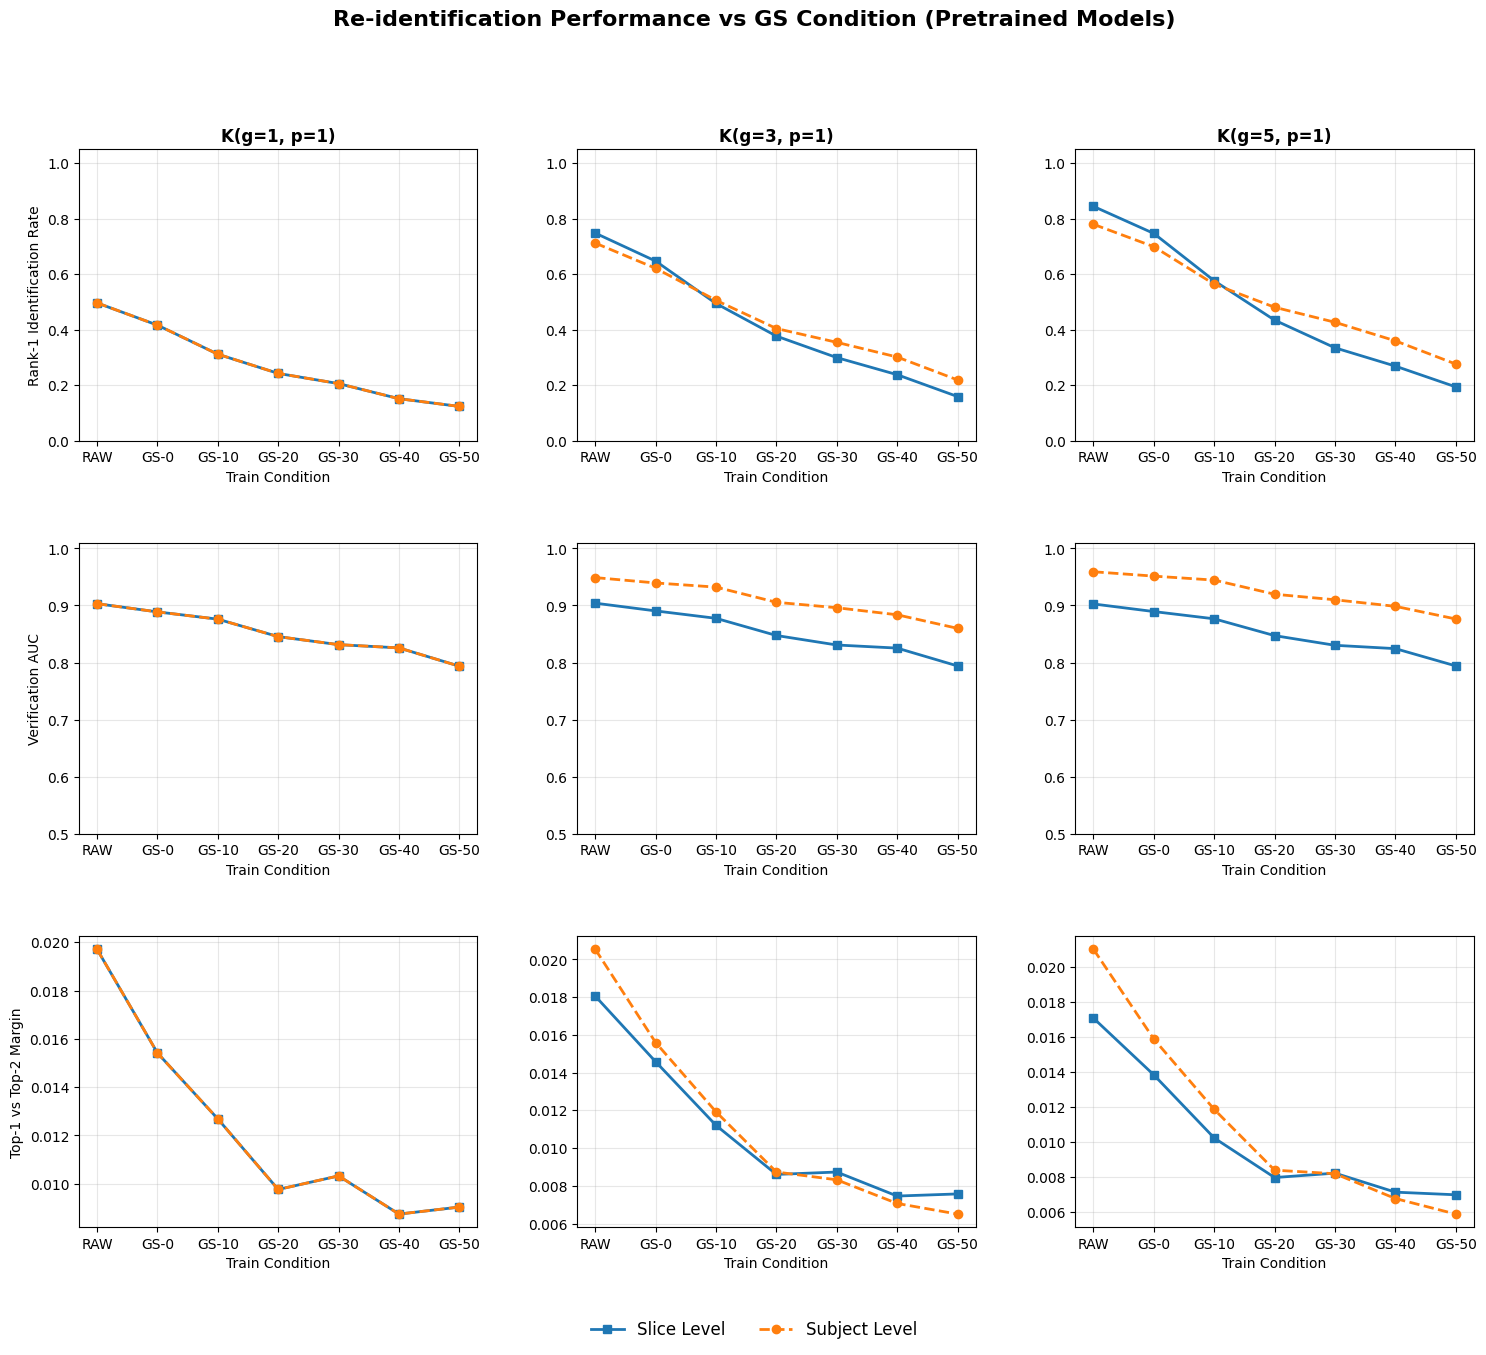

Saved: /home/jupyter/notebooks/reid_clean/results/oasis/reid_feature_ext/reid_plots/reid_pretrained_3x3_summary.png


In [6]:
# ==========================================
# PLOTTING CELL — FIXED VERSION
# ==========================================

from matplotlib.gridspec import GridSpec
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# -------------------------------------------------
# Load results
# -------------------------------------------------
RESULTS_CSV = Path(
    "./results/oasis/reid_feature_ext/OASIS_ReID_FeatureExt.csv"
)
df = pd.read_csv(RESULTS_CSV)

# -------------------------------------------------
# Parse condition (RAW, GS0..GS50)
# -------------------------------------------------
def parse_condition(cond: str):
    """
    Returns (cond_label, cond_sort).
    Important: RAW and GS0 must NOT share the same sort key.
    """
    c = str(cond).strip().lower()

    if c == "raw":
        return ("RAW", -1)  # RAW sorts before GS0

    m = re.match(r"gs(\d+)$", c)
    if m:
        k = int(m.group(1))
        return (f"GS-{k}", k)

    raise ValueError(f"Unknown train_condition: {cond}")


for col in ["cond_label", "cond_sort"]:
    if col in df.columns:
        df = df.drop(columns=[col])

tmp = df["train_condition"].apply(parse_condition)
df["cond_label"] = tmp.apply(lambda x: x[0])
df["cond_sort"] = tmp.apply(lambda x: x[1])

# -------------------------------------------------
# Output directory
# -------------------------------------------------
BASE_OUT = RESULTS_DIR / "reid_plots"
BASE_OUT.mkdir(exist_ok=True)

# -------------------------------------------------
# Filter: pretrained only
# -------------------------------------------------
df_pre = df[df["init"] == "pretrained"].copy()

# -------------------------------------------------
# Aggregate ONCE
# -------------------------------------------------
agg_pre = (
    df_pre
    .groupby([
        "k_gallery",
        "k_probe",
        "cond_label",
        "cond_sort",
        "level",
        "attacker_type",
    ])
    .agg({
        "rank1": "mean",
        "auc": "mean",
        "margin": "mean",
    })
    .reset_index()
    .sort_values(["k_gallery", "cond_sort", "level"])
)

# -------------------------------------------------
# Figure: 3 × 3 layout
# -------------------------------------------------
fig = plt.figure(figsize=(18, 14))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.25)

K_LIST = [(1, 1), (3, 1), (5, 1)]

# We'll collect handles/labels from the first plot for global legend
GLOBAL_HANDLES = None
GLOBAL_LABELS = None

for col, (kg, kp) in enumerate(K_LIST):
    df_k = agg_pre[(agg_pre.k_gallery == kg) & (agg_pre.k_probe == kp)].copy()

    # ---------------- Row 0: Rank-1 ----------------
    ax = fig.add_subplot(gs[0, col])
    plt.sca(ax)
    plot_rank1_curves(df_k, save=False)  # save=False for multi-panel
    ax.set_title(f"K(g={kg}, p={kp})", fontsize=12, fontweight="bold")
    if col == 0:
        ax.set_ylabel("Rank-1 Identification Rate")
    else:
        ax.set_ylabel("")
    ax.get_legend().remove()  # Remove individual legends

    # ---------------- Row 1: AUC ----------------
    ax = fig.add_subplot(gs[1, col])
    plt.sca(ax)
    plot_auc_curves(df_k, save=False)
    ax.set_title("")  # No title for middle/bottom rows
    if col == 0:
        ax.set_ylabel("Verification AUC")
    else:
        ax.set_ylabel("")
    ax.get_legend().remove()

    # ---------------- Row 2: Margin ----------------
    ax = fig.add_subplot(gs[2, col])
    plt.sca(ax)
    plot_margin_curves(df_k, save=False)
    ax.set_title("")
    if col == 0:
        ax.set_ylabel("Top-1 vs Top-2 Margin")
    else:
        ax.set_ylabel("")
    
    # Capture legend handles from the last subplot
    handles, labels = ax.get_legend_handles_labels()
    if handles and GLOBAL_HANDLES is None:
        GLOBAL_HANDLES = handles
        GLOBAL_LABELS = labels
    ax.get_legend().remove()

# -------------------------------------------------
# Global legend (bottom center)
# -------------------------------------------------
if GLOBAL_HANDLES and GLOBAL_LABELS:
    fig.legend(
        GLOBAL_HANDLES,
        GLOBAL_LABELS,
        loc="lower center",
        ncol=len(GLOBAL_LABELS),
        frameon=False,
        fontsize=12,
        bbox_to_anchor=(0.5, 0.02),
    )

fig.suptitle(
    "Re-identification Performance vs GS Condition (Pretrained Models)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])

# -------------------------------------------------
# Save final figure
# -------------------------------------------------
fig.savefig(
    BASE_OUT / "reid_pretrained_3x3_summary.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
print("Saved:", BASE_OUT / "reid_pretrained_3x3_summary.png")

#### Scratch Results - Appendix

/var/tmp/ipykernel_6918/3995567187.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/tmp/ipykernel_6918/3995567187.py:244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/tmp/ipykernel_6918/3995567187.py:333: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/tmp/ipykernel_6918/3995567187.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/tmp/ipykernel_6918/3995567187.py:244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/tmp/ipykernel_6918/3995567187.py:333: UserWarning: This figure includes Axes that are not compatible with tigh

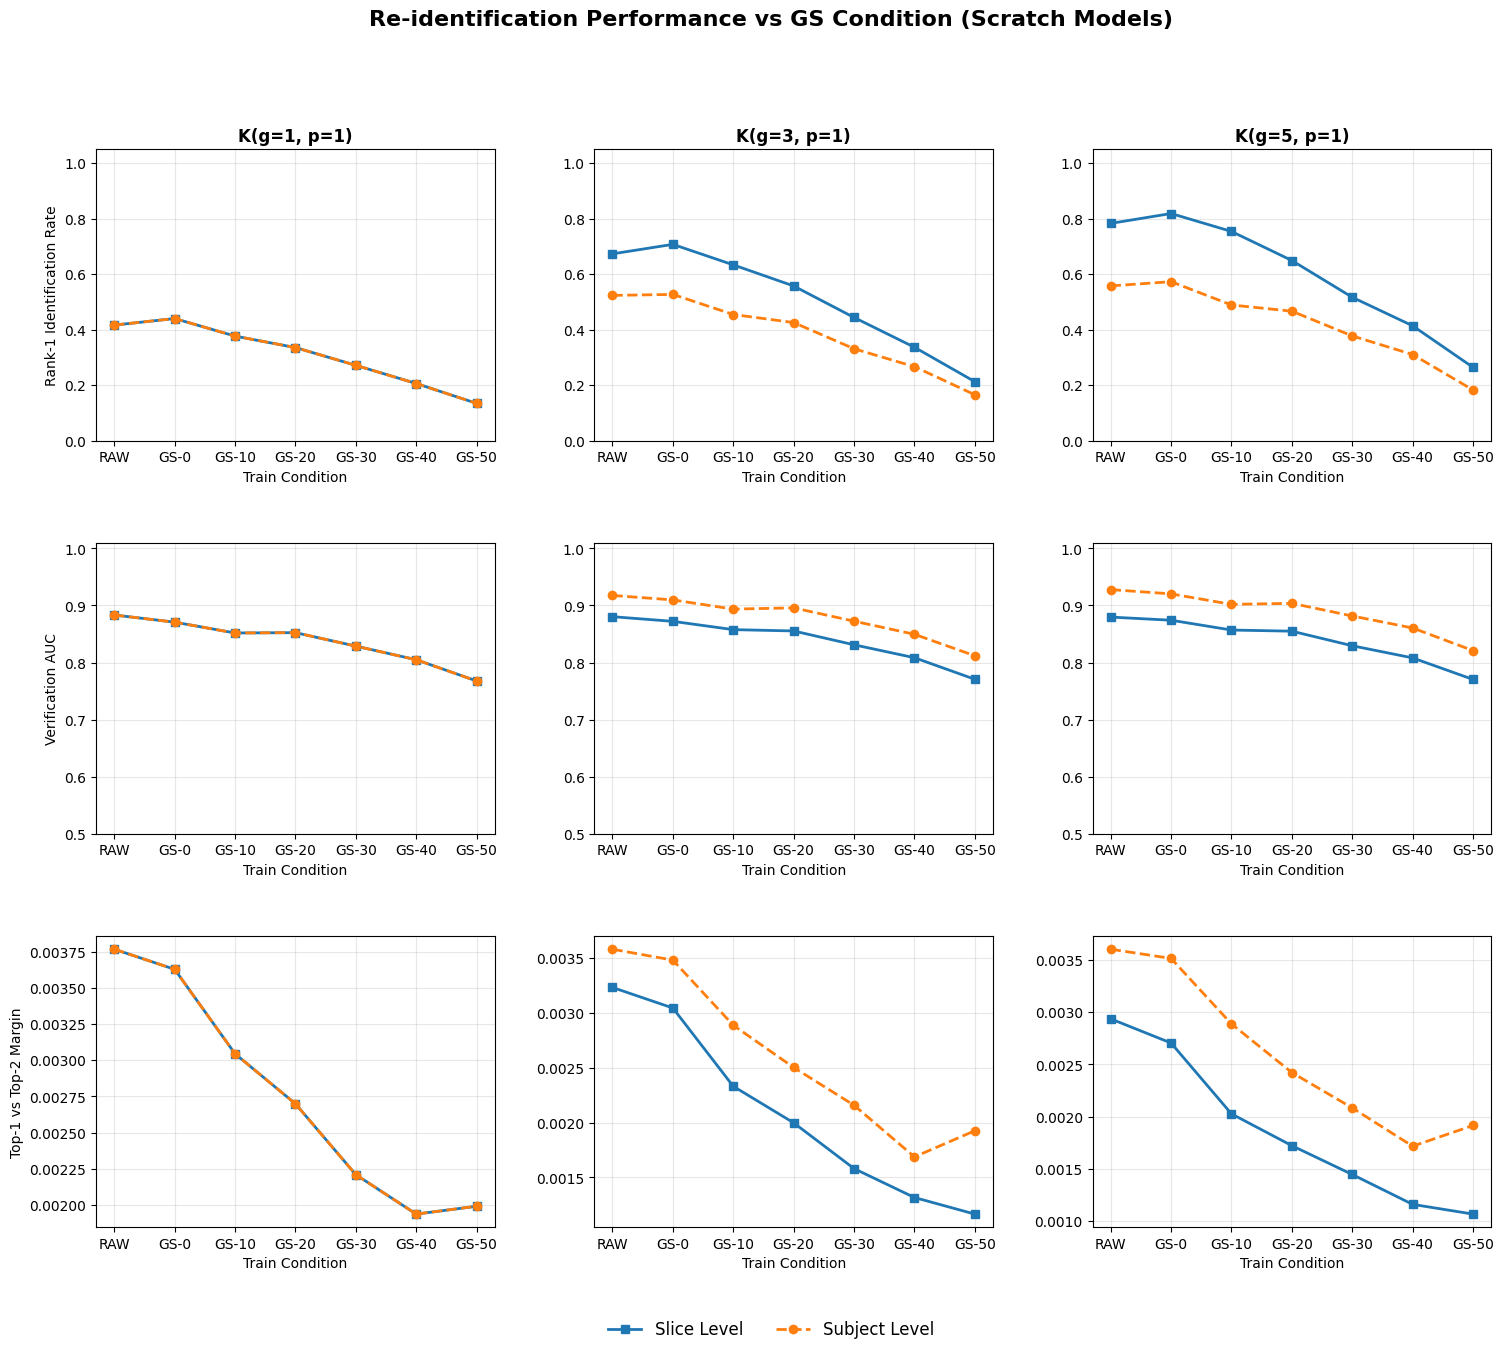

Saved: /home/jupyter/notebooks/reid_clean/results/oasis/reid_feature_ext/reid_plots/reid_scratch_3x3_summary.png


In [7]:
# ==========================================
# PLOTTING CELL — FIXED VERSION
# ==========================================

from matplotlib.gridspec import GridSpec
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# -------------------------------------------------
# Load results
# -------------------------------------------------
RESULTS_CSV = Path(
    "./results/oasis/reid_feature_ext/OASIS_ReID_FeatureExt.csv"
)
df = pd.read_csv(RESULTS_CSV)

# -------------------------------------------------
# Parse condition (RAW, GS0..GS50)
# -------------------------------------------------
def parse_condition(cond: str):
    """
    Returns (cond_label, cond_sort).
    Important: RAW and GS0 must NOT share the same sort key.
    """
    c = str(cond).strip().lower()

    if c == "raw":
        return ("RAW", -1)  # RAW sorts before GS0

    m = re.match(r"gs(\d+)$", c)
    if m:
        k = int(m.group(1))
        return (f"GS-{k}", k)

    raise ValueError(f"Unknown train_condition: {cond}")


for col in ["cond_label", "cond_sort"]:
    if col in df.columns:
        df = df.drop(columns=[col])

tmp = df["train_condition"].apply(parse_condition)
df["cond_label"] = tmp.apply(lambda x: x[0])
df["cond_sort"] = tmp.apply(lambda x: x[1])

# -------------------------------------------------
# Output directory
# -------------------------------------------------
BASE_OUT = RESULTS_DIR / "reid_plots"
BASE_OUT.mkdir(exist_ok=True)

# -------------------------------------------------
# Filter: pretrained only
# -------------------------------------------------
df_scr = df[df["init"] == "scratch"].copy()

# -------------------------------------------------
# Aggregate ONCE
# -------------------------------------------------
agg_scr = (
    df_scr
    .groupby([
        "k_gallery",
        "k_probe",
        "cond_label",
        "cond_sort",
        "level",
        "attacker_type",
    ])
    .agg({
        "rank1": "mean",
        "auc": "mean",
        "margin": "mean",
    })
    .reset_index()
    .sort_values(["k_gallery", "cond_sort", "level"])
)

# -------------------------------------------------
# Figure: 3 × 3 layout
# -------------------------------------------------
fig = plt.figure(figsize=(18, 14))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.25)

K_LIST = [(1, 1), (3, 1), (5, 1)]

# We'll collect handles/labels from the first plot for global legend
GLOBAL_HANDLES = None
GLOBAL_LABELS = None

for col, (kg, kp) in enumerate(K_LIST):
    df_k = agg_scr[(agg_scr.k_gallery == kg) & (agg_scr.k_probe == kp)].copy()

    # ---------------- Row 0: Rank-1 ----------------
    ax = fig.add_subplot(gs[0, col])
    plt.sca(ax)
    plot_rank1_curves(df_k, save=False)  # save=False for multi-panel
    ax.set_title(f"K(g={kg}, p={kp})", fontsize=12, fontweight="bold")
    if col == 0:
        ax.set_ylabel("Rank-1 Identification Rate")
    else:
        ax.set_ylabel("")
    ax.get_legend().remove()  # Remove individual legends

    # ---------------- Row 1: AUC ----------------
    ax = fig.add_subplot(gs[1, col])
    plt.sca(ax)
    plot_auc_curves(df_k, save=False)
    ax.set_title("")  # No title for middle/bottom rows
    if col == 0:
        ax.set_ylabel("Verification AUC")
    else:
        ax.set_ylabel("")
    ax.get_legend().remove()

    # ---------------- Row 2: Margin ----------------
    ax = fig.add_subplot(gs[2, col])
    plt.sca(ax)
    plot_margin_curves(df_k, save=False)
    ax.set_title("")
    if col == 0:
        ax.set_ylabel("Top-1 vs Top-2 Margin")
    else:
        ax.set_ylabel("")
    
    # Capture legend handles from the last subplot
    handles, labels = ax.get_legend_handles_labels()
    if handles and GLOBAL_HANDLES is None:
        GLOBAL_HANDLES = handles
        GLOBAL_LABELS = labels
    ax.get_legend().remove()

# -------------------------------------------------
# Global legend (bottom center)
# -------------------------------------------------
if GLOBAL_HANDLES and GLOBAL_LABELS:
    fig.legend(
        GLOBAL_HANDLES,
        GLOBAL_LABELS,
        loc="lower center",
        ncol=len(GLOBAL_LABELS),
        frameon=False,
        fontsize=12,
        bbox_to_anchor=(0.5, 0.02),
    )

fig.suptitle(
    "Re-identification Performance vs GS Condition (Scratch Models)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])

# -------------------------------------------------
# Save final figure
# -------------------------------------------------
fig.savefig(
    BASE_OUT / "reid_scratch_3x3_summary.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
print("Saved:", BASE_OUT / "reid_scratch_3x3_summary.png")

### Upper-Bound Stress Test (K=61, P=1) - Optional/Appendix

In [ ]:
# ==========================================
# CELL: K=61 STRESS TEST — UPPER BOUND EXPERIMENT
# (Uses all available slices per subject, no K caps)
# ==========================================

# Output paths for K=61 results
MASTER_CSV_K61 = RESULTS_DIR / "OASIS_ReID_FeatureExt_K61.csv"

def run_reid_k61_stress_test():
    """
    Upper-bound stress test: use all available slices per subject.
    No k_gallery or k_probe caps — natural 50/50 split.
    """
    rows = []

    for fold in FOLDS:
        for eval_split in ["train", "test"]:
            
            # Step 1: Build gallery/probe ONCE per (fold, split) — no K caps
            gp_raw = build_gallery_probe_raw(
                fold_idx=fold,
                split=eval_split,
                k_gallery=None,  # No cap — use all
                k_probe=None,    # No cap — use all
            )
            
            # Step 2: Pre-compute GS transforms for all unique eval_conditions
            transformed_cache = {}
            
            for train_condition in CONDITIONS:
                for attacker in ["adaptive", "blind"]:
                    if train_condition == "raw" and attacker == "blind":
                        continue
                    
                    eval_condition = train_condition if attacker == "adaptive" else "raw"
                    
                    if eval_condition not in transformed_cache:
                        g_x = apply_gs_to_tensor(gp_raw["gallery"]["x"], eval_condition)
                        p_x = apply_gs_to_tensor(gp_raw["probe"]["x"], eval_condition)
                        transformed_cache[eval_condition] = (g_x, p_x)
            
            # Step 3: Loop over models
            for arch in ARCHS:
                for init_mode in INITS:
                    for train_condition in CONDITIONS:
                        for attacker in ["adaptive", "blind"]:
                            if train_condition == "raw" and attacker == "blind":
                                continue
                            
                            eval_condition = train_condition if attacker == "adaptive" else "raw"
                            g_x, p_x = transformed_cache[eval_condition]
                            
                            g_sid = gp_raw["gallery"]["sid"]
                            p_sid = gp_raw["probe"]["sid"]
                            
                            # Load model and extract embeddings
                            model = load_utility_model(arch, init_mode, train_condition, fold)
                            embedder = build_penultimate_extractor(model, arch)
                            
                            g_emb = extract_embeddings(g_x, embedder)
                            p_emb = extract_embeddings(p_x, embedder)
                            
                            # Subject-level aggregation
                            g_subj_emb, g_subj_ids = mean_embeddings_by_subject(g_emb, g_sid)
                            p_subj_emb, p_subj_ids = mean_embeddings_by_subject(p_emb, p_sid)
                            
                            inter = sorted(set(g_subj_ids) & set(p_subj_ids))
                            if not inter:
                                _hard_fail("No subject overlap")
                            
                            g_map = {s: i for i, s in enumerate(g_subj_ids)}
                            p_map = {s: i for i, s in enumerate(p_subj_ids)}
                            g_keep = [g_map[s] for s in inter]
                            p_keep = [p_map[s] for s in inter]
                            
                            meta = {
                                "fold": fold,
                                "arch": arch,
                                "init": init_mode,
                                "train_condition": train_condition,
                                "attacker_type": attacker,
                                "eval_split": eval_split,
                                "eval_condition": eval_condition,
                                "seed": GLOBAL_SEED,
                                "k_gallery": -1,  # -1 indicates no cap (all slices)
                                "k_probe": -1,
                            }
                            
                            # Compute metrics for both levels
                            for level in ["slice_level", "subject_level"]:
                                if level == "slice_level":
                                    ge, pe, gs, ps = g_emb, p_emb, g_sid, p_sid
                                else:
                                    ge = g_subj_emb[g_keep]
                                    pe = p_subj_emb[p_keep]
                                    gs, ps = inter, inter
                                
                                retrieval = compute_retrieval_metrics(pe, ps, ge, gs)
                                
                                run_seed = (
                                    GLOBAL_SEED
                                    + 1000 * fold
                                    + 10 * CONDITIONS.index(train_condition)
                                    + (0 if attacker == "adaptive" else 1)
                                    + (0 if eval_split == "train" else 2)
                                    + (0 if level == "slice_level" else 4)
                                )
                                
                                verification = compute_verification_metrics_bounded(
                                    pe, ps, ge, gs,
                                    neg_per_probe=(200 if level == "slice_level" else 500),
                                    seed=run_seed
                                )
                                
                                row = {**meta, "level": level, **retrieval, **verification}
                                rows.append(row)
                                
                                print(
                                    f"[K61] fold{fold} {eval_split} "
                                    f"{arch} {init_mode} {train_condition} "
                                    f"{attacker} {level} "
                                    f"R1={retrieval['rank1']:.3f} "
                                    f"AUC={verification['auc']:.3f}"
                                )
            
            # Clear cache to free memory
            del transformed_cache

    df = pd.DataFrame(rows)
    df.to_csv(MASTER_CSV_K61, index=False)
    print(f"\n✅ K=61 stress test saved to {MASTER_CSV_K61} ({len(df)} rows)")


# Run K=61 stress test
run_reid_k61_stress_test()

Batch 46 of 46 (full batch) completed...
Batch 46 of 46 (full batch) completed...)...
Batch 46 of 46 (full batch) completed...1)...
Batch 46 of 46 (full batch) completed...)...
Batch 46 of 46 (full batch) completed...1)...
Batch 46 of 46 (full batch) completed...)...
Batch 46 of 46 (full batch) completed...1)...
Batch 46 of 46 (full batch) completed...)...
Batch 46 of 46 (full batch) completed...1)...
Batch 46 of 46 (full batch) completed...)...
Batch 46 of 46 (full batch) completed...1)...
Batch 46 of 46 (full batch) completed...)...
Remaining data batch completed (size: 121)...[K61] fold0 train densenet121 pretrained raw adaptive slice_level R1=0.997 AUC=0.912
[K61] fold0 train densenet121 pretrained raw adaptive subject_level R1=1.000 AUC=1.000
[K61] fold0 train densenet121 pretrained gs0 adaptive slice_level R1=0.988 AUC=0.896
[K61] fold0 train densenet121 pretrained gs0 adaptive subject_level R1=1.000 AUC=1.000
[K61] fold0 train densenet121 pretrained gs0 blind slice_level R1=1.00

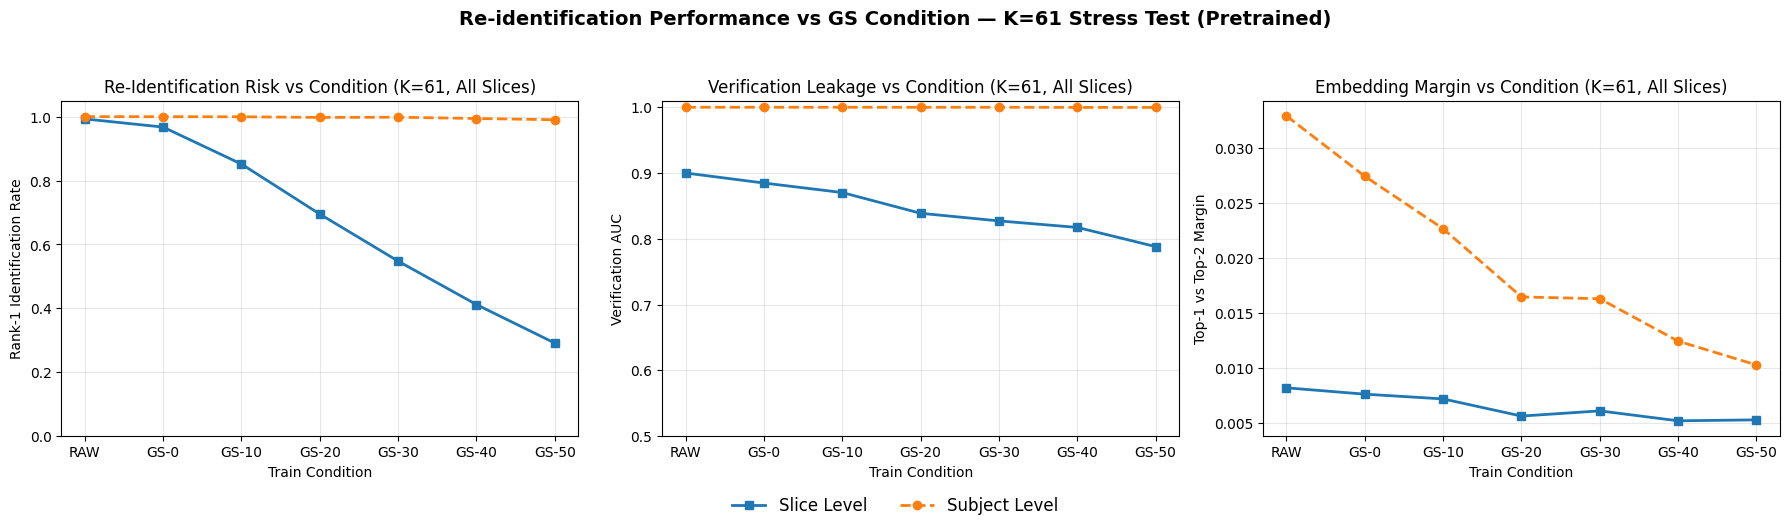

Saved: /home/jupyter/notebooks/reid_clean/results/oasis/reid_feature_ext/reid_plots_k61/reid_pretrained_k61_summary.png


In [8]:
# ==========================================
# PLOTTING CELL — K=61 STRESS TEST RESULTS
# ==========================================

from matplotlib.gridspec import GridSpec
import re

# -------------------------------------------------
# Load K=61 results
# -------------------------------------------------
RESULTS_CSV_K61 = RESULTS_DIR / "OASIS_ReID_FeatureExt_K61.csv"
df_k61 = pd.read_csv(RESULTS_CSV_K61)

# -------------------------------------------------
# Parse condition (RAW, GS0..GS50)
# -------------------------------------------------
def parse_condition(cond: str):
    c = str(cond).strip().lower()
    if c == "raw":
        return ("RAW", -1)
    m = re.match(r"gs(\d+)$", c)
    if m:
        k = int(m.group(1))
        return (f"GS-{k}", k)
    raise ValueError(f"Unknown train_condition: {cond}")

for col in ["cond_label", "cond_sort"]:
    if col in df_k61.columns:
        df_k61 = df_k61.drop(columns=[col])

tmp = df_k61["train_condition"].apply(parse_condition)
df_k61["cond_label"] = tmp.apply(lambda x: x[0])
df_k61["cond_sort"] = tmp.apply(lambda x: x[1])

# -------------------------------------------------
# Output directory
# -------------------------------------------------
BASE_OUT_K61 = RESULTS_DIR / "reid_plots_k61"
BASE_OUT_K61.mkdir(exist_ok=True)

# -------------------------------------------------
# Filter: pretrained only
# -------------------------------------------------
df_k61_pre = df_k61[df_k61["init"] == "pretrained"].copy()

# -------------------------------------------------
# Aggregate
# -------------------------------------------------
agg_k61 = (
    df_k61_pre
    .groupby([
        "cond_label",
        "cond_sort",
        "level",
        "attacker_type",
    ])
    .agg({
        "rank1": "mean",
        "auc": "mean",
        "margin": "mean",
    })
    .reset_index()
    .sort_values(["cond_sort", "level"])
)

# -------------------------------------------------
# Figure: 1 × 3 layout (single K setting)
# -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rank-1
plt.sca(axes[0])
plot_rank1_curves(agg_k61, t_add="(K=61, All Slices)", save=False)
axes[0].set_ylabel("Rank-1 Identification Rate")

# AUC
plt.sca(axes[1])
plot_auc_curves(agg_k61, t_add="(K=61, All Slices)", save=False)
axes[1].set_ylabel("Verification AUC")

# Margin
plt.sca(axes[2])
plot_margin_curves(agg_k61, t_add="(K=61, All Slices)", save=False)
axes[2].set_ylabel("Top-1 vs Top-2 Margin")

# Global legend
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    leg = ax.get_legend()
    if leg:
        leg.remove()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(labels),
    frameon=False,
    fontsize=12,
    bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle(
    "Re-identification Performance vs GS Condition — K=61 Stress Test (Pretrained)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout(rect=[0, 0.05, 1, 0.98])

# Save
fig.savefig(
    BASE_OUT_K61 / "reid_pretrained_k61_summary.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
print("Saved:", BASE_OUT_K61 / "reid_pretrained_k61_summary.png")